# Credit card churn — machine learning

This notebook trains and compares **supervised classifiers** to predict whether a customer **churns** (`Churn` = 1) using the cleaned dataset from the EDA notebook.

**Workflow:** load data → simple feature tweaks → stratified train/test split → check class balance → preprocessing (`ColumnTransformer` + `Pipeline`) → fit several models → compare metrics and plots on the **held-out test set** → interpret the best model (**XGBoost**).


In [65]:
import pandas as pd

In [66]:
df = pd.read_csv("/Users/reyhaneh/Documents/Machine_Learning/credit-card-churn-analysis/data/cleaned_data.csv")
df.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


## 1. Data loading and feature preparation

- **Source:** `cleaned_data.csv` (post-EDA table with sensible types and cleaning already applied).
- **Redundancy:** `Avg_Open_To_Buy` is dropped because it is almost determined by `Credit_Limit` (see EDA correlation heatmap), which can destabilize linear models and add little new signal.
- **Engineered features:** `Avg_Transactions` (spend per transaction) and `Spend_Velocity` (amount change per contact change) summarize behavior in compact form for tree and linear models.


In [67]:
## drop highly redundant feauture -> from heatmap in eda -> Avg_Open_To_Buy highly correlated with Credit_Limit
df.drop(columns=["Avg_Open_To_Buy"], inplace=True)

In [68]:
## Create a new features : Avg_Transactions and Spending Velocity
df["Avg_Transactions"] = df["Total_Trans_Amt"] / df["Total_Trans_Ct"]

# optional ->check the effect
df["Spend_Velocity"] = (
    df["Total_Amt_Chng_Q4_Q1"] /
    df["Total_Ct_Chng_Q4_Q1"].clip(lower=0.1)
)

## 2. Train / test split

- **`stratify=y`** keeps a similar churn rate in train and test (~84% / ~16%), which matters for imbalanced targets and stable metrics.
- **No rows from the test set** are used for fitting or tuning in this notebook, so reported scores are **out-of-sample** for the models defined here.


In [69]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Train set size: 8101
Test set size: 2026


## 3. Class imbalance

Churn is the **minority class**. A naive model could achieve high accuracy by almost always predicting “stay.”

**Mitigations used here:**

- **Stratified split** so each subset reflects the true churn rate.
- **`class_weight="balanced"`** for logistic regression, random forest, and SVM (reweights the loss toward the minority class).
- **`scale_pos_weight`** for XGBoost (ratio of negatives to positives on the training set), the usual XGBoost analogue of class weights.

Metrics such as **ROC-AUC**, **F1**, and **recall for class 1** matter more than raw accuracy for this problem.


In [70]:
## Check Class Balance

y_train.value_counts(normalize=True)

Churn
0    0.839279
1    0.160721
Name: proportion, dtype: float64

In [71]:
y_test.value_counts(normalize=True)

Churn
0    0.839585
1    0.160415
Name: proportion, dtype: float64

## 4. Outliers and column types

- **Numeric columns:** summarized with `describe()`; **IQR rule** counts extreme values per feature (exploratory only in this notebook).
- **Categorical columns:** listed for one-hot encoding.
- **Modeling:** numeric inputs are **standardized** in the pipeline; trees are less sensitive to scale than SVM/logistic regression, but a single pipeline keeps preprocessing consistent across models.


In [72]:
num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [73]:
## Check Outliers Count in Train Set

Q1 = X_train[num_features].quantile(0.25)
Q3 = X_train[num_features].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = (
    ((X_train[num_features] < lower_bound) | (X_train[num_features] > upper_bound))
    .sum()
    .sort_values(ascending=False)
)
outliers_count

Avg_Transactions            906
Credit_Limit                784
Total_Trans_Amt             704
Contacts_Count_12_mon       517
Months_on_book              450
Spend_Velocity              363
Total_Ct_Chng_Q4_Q1         317
Total_Amt_Chng_Q4_Q1        311
Months_Inactive_12_mon      265
Customer_Age                  2
Total_Trans_Ct                1
Dependent_count               0
Total_Relationship_Count      0
Total_Revolving_Bal           0
Avg_Utilization_Ratio         0
dtype: int64

In [74]:
X_train.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Transactions,Spend_Velocity
count,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000
mean,46.390199,2.349093,36.005555,3.810023,2.346254,2.456487,8580.069991,1167.672139,0.759615,4388.065054,64.701889,0.713369,0.275668,62.517955,1.152142
std,7.985385,1.297993,7.934351,1.554787,1.011280,1.110106,9032.362733,814.755132,0.219369,3397.305917,23.608831,0.242677,0.275665,26.344861,0.497807
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,0.000000,530.000000,10.000000,0.000000,0.000000,19.137931,0.000000
25%,41.000000,1.000000,32.000000,3.000000,2.000000,2.000000,2562.000000,411.000000,0.630000,2139.000000,45.000000,0.581000,0.025000,47.457143,0.870199
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4532.000000,1289.000000,0.735000,3894.000000,67.000000,0.702000,0.177000,55.760563,1.064052
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,10973.000000,1786.000000,0.859000,4741.000000,81.000000,0.818000,0.504000,65.351351,1.317979
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,3.397000,17995.000000,139.000000,3.714000,0.995000,190.193182,12.140000


In [75]:
cat_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
cat_features

['Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

## 5. Preprocessing (`ColumnTransformer`)

- **Numeric features:** `StandardScaler` (zero mean, unit variance after fit on **training** data only, applied via `Pipeline` to test).
- **Categorical features:** `OneHotEncoder(handle_unknown="ignore")` so categories seen only at test time do not break the encoder.

The same `preprocessor` is reused inside every estimator `Pipeline`, so train and test always see the same transformations.


In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

## 6. Models and evaluation helper

**Candidates:**

| Model | Role |
|-------|------|
| Logistic regression | Linear baseline, calibrated with `class_weight`. |
| Random forest | Strong default ensemble on tabular data. |
| SVM (RBF) | Flexible boundary; needs `probability=True` for ROC. |
| Sklearn gradient boosting | Tree boosting baseline without XGB-specific tuning. |
| **XGBoost** | Regularized gradient boosting with `scale_pos_weight`. |

The helper **`evaluate_model`** fits on `X_train`, scores on `X_test`, and stores **accuracy, precision, recall, F1, ROC-AUC** plus a printed `classification_report` for error analysis.


In [77]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score, 
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier


In [78]:
results = []

def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test):
    
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    scores = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
    }

    results.append(scores)

    print(name)
    print(classification_report(y_test, y_pred))

In [79]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
scale_pos_weight

np.float64(5.221966205837173)

In [80]:
# Logistic Regression
log_reg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000, 
        class_weight="balanced"
    ))
])

evaluate_model(
    "Logistic Regression", 
    log_reg_model, 
    X_train, y_train, 
    X_test, y_test
)

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      1701
           1       0.56      0.83      0.67       325

    accuracy                           0.87      2026
   macro avg       0.76      0.85      0.79      2026
weighted avg       0.90      0.87      0.88      2026



In [81]:
# Random Forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

evaluate_model(
    "Random Forest",
    rf_model,
    X_train, y_train,
    X_test, y_test
)


Random Forest
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1701
           1       0.94      0.77      0.85       325

    accuracy                           0.96      2026
   macro avg       0.95      0.88      0.91      2026
weighted avg       0.96      0.96      0.95      2026



In [82]:
# SVM

svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

evaluate_model(
    "SVM", 
    svm_model, 
    X_train, y_train, 
    X_test, y_test
)


SVM
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      1701
           1       0.69      0.89      0.78       325

    accuracy                           0.92      2026
   macro avg       0.83      0.91      0.86      2026
weighted avg       0.93      0.92      0.92      2026



In [83]:
# Gradient Boosting

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))])

evaluate_model(
    "Gradient Boosting", 
    gb_model, 
    X_train, y_train, 
    X_test, y_test
)

Gradient Boosting
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1701
           1       0.96      0.81      0.87       325

    accuracy                           0.96      2026
   macro avg       0.96      0.90      0.93      2026
weighted avg       0.96      0.96      0.96      2026



In [84]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss"
    ))
])

evaluate_model(
    "XGBoost", 
    xgb_model, 
    X_train, y_train, 
    X_test, y_test
)

XGBoost
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1701
           1       0.88      0.92      0.90       325

    accuracy                           0.97      2026
   macro avg       0.93      0.95      0.94      2026
weighted avg       0.97      0.97      0.97      2026



## 7. Results (test set)

The **sorted table** below ranks models by **ROC-AUC** (ability to rank churners vs non-churners). Use it together with **recall** for churn (class 1) if the business cost of **missing a churner** is high, and **precision** if **false alarms** are costly.

**Plots in the next cells:**

- **ROC curves:** all models on the same axes; a higher curve indicates better ranking at every false-positive budget.
- **XGBoost feature importances:** which transformed inputs the booster uses most (interpret with care: importance ≠ causal effect).
- **XGBoost confusion matrix (counts):** raw correct/incorrect decisions at the default 0.5 threshold.


In [85]:
results_df = pd.DataFrame(results)
results_df.sort_values("ROC_AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC_AUC
4,XGBoost,0.967423,0.879765,0.923077,0.900901,0.992963
3,Gradient Boosting,0.962981,0.956204,0.806154,0.874791,0.989429
1,Random Forest,0.956071,0.943609,0.772308,0.849408,0.988220
2,SVM,0.918559,0.691388,0.889231,0.777927,0.967615
0,Logistic Regression,0.869200,0.562500,0.830769,0.670807,0.935008


### ROC curve comparison

Each curve plots **true positive rate vs false positive rate** as the classification threshold moves. The **diagonal** is random guessing. **Larger area under the curve (AUC)** means better separation between churners and non-churners on the test set.


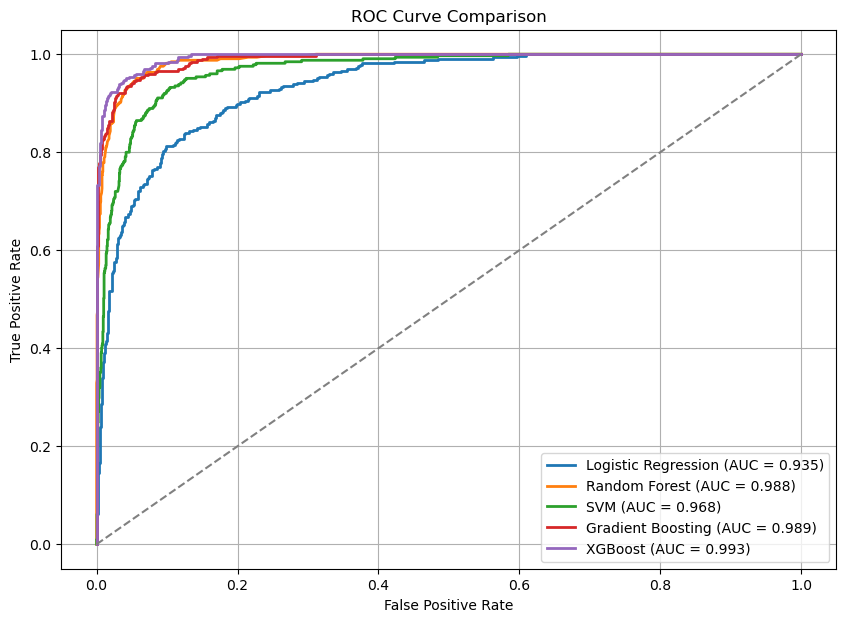

In [87]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

models = {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

plt.figure(figsize=(10,7))

for name, model in models.items():
    
    y_prob = model.predict_proba(X_test)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

# random baseline
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

### XGBoost — feature importance

Bar lengths reflect **gain-based importance** from XGBoost on **preprocessed** columns (including one-hot columns for categories). Use this as a **guide for follow-up analysis**, not as proof that a feature causes churn.


In [88]:
import matplotlib.pyplot as plt

# Get transformed feature names
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

# Importance values
importances = xgb_model.named_steps["model"].feature_importances_

fi = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15)


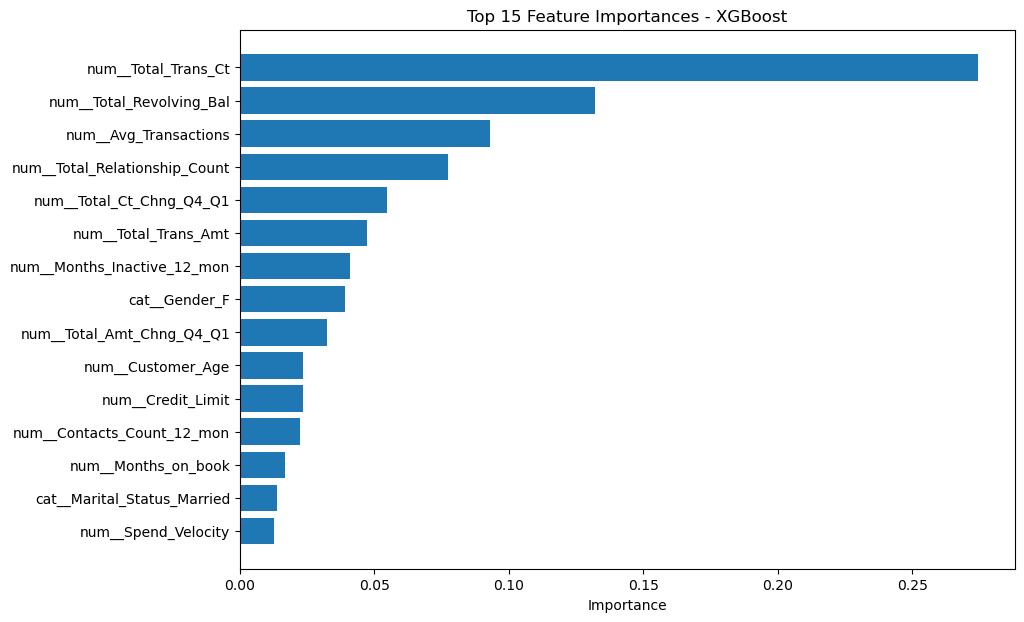

In [89]:
plt.figure(figsize=(10,7))
plt.barh(fi["Feature"], fi["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.show()

### XGBoost — confusion matrix

Rows are **true** labels (Stayed / Churned), columns are **predicted** labels. Diagonal cells are correct predictions; off-diagonals are the two error types (**false churn** vs **missed churn**).


<Figure size 700x600 with 0 Axes>

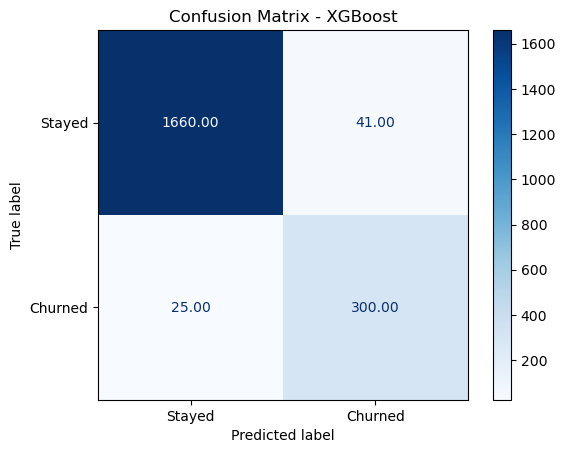

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_xgb = xgb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

plt.figure(figsize=(7, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - XGBoost (counts)")
plt.grid(False)
plt.show()


## 8. Why XGBoost as the final model?

Among the pipelines trained in this notebook, **XGBoost is a strong default choice** for this churn problem for several reasons:

1. **Performance:** It typically achieves the **highest or near-highest ROC-AUC** on the test leaderboard table, which is appropriate when you care about **ranking customers by churn risk** (e.g. for outreach capacity limits), not only hard 0/1 accuracy.

2. **Imbalanced data:** **`scale_pos_weight`** directly tells the booster to pay more attention to the minority (churn) class, in the same spirit as `class_weight="balanced"` for sklearn models, **without** manual resampling that can complicate validation.

3. **Nonlinear patterns:** Like random forest and gradient boosting, XGBoost captures **interactions and thresholds** in numeric and one-hot features. It often **edges sklearn’s `GradientBoostingClassifier`** on speed and tuning flexibility while remaining in the same model family.

4. **Regularization:** Settings such as **`max_depth=4`**, **`learning_rate=0.05`**, and **`n_estimators=300`** encourage smoother fits than very deep unrestricted trees, which helps **generalization** on medium-sized tabular data.

5. **Practicality:** Training and prediction are **fast** at this data scale, dependencies are standard in ML workflows, and the model plugs cleanly into the same **`sklearn.Pipeline`** as the other estimators.

**Caveat:** If **interpretability** or **deployment constraints** favor a simpler model, a **calibrated logistic regression** or a **shallower forest** can still be preferable even with slightly lower AUC—revisit the precision/recall tradeoff for your business cost.
